In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

# Steps

### 0. Preprocess + EDA + Feature Selection
### 1. Extract input and output cols
### 2. Scale the Values
### 3. Train test Split
### 4. Train the model
### 5. Evaluate the model/model selection
### 6. Deploy the model

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
import matplotlib.pyplot as plt

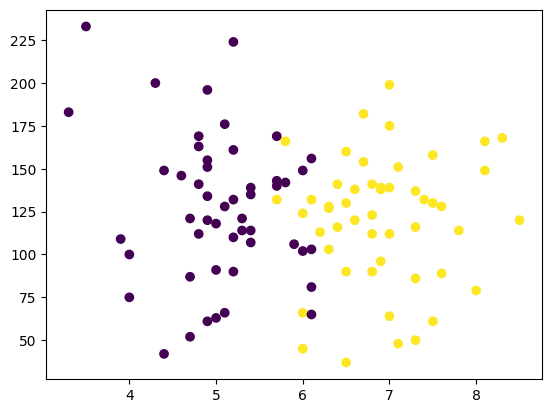

In [9]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [10]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [11]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [12]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [14]:
X_train

,cgpa,iq
35,6.8,90.0
11,6.9,138.0
84,5.7,169.0
44,7.5,61.0
73,4.9,61.0
...,...,...
43,6.8,141.0
22,4.9,120.0
72,7.3,116.0
15,5.1,176.0


In [15]:
y_train

35    1
11    1
84    0
44    1
73    0
     ..
43    1
22    0
72    1
15    0
40    0
Name: placement, Length: 80, dtype: int64

In [16]:
X_test

,cgpa,iq
83,7.5,130.0
30,7.6,128.0
56,6.1,65.0
24,4.7,121.0
16,5.2,224.0
23,4.7,87.0
2,5.3,121.0
27,6.0,124.0
28,5.2,90.0
13,6.4,116.0


In [17]:
y_test

83    1
30    1
56    0
24    0
16    0
23    0
2     0
27    1
28    0
13    1
99    1
92    0
76    0
14    0
0     1
21    1
3     1
29    1
61    1
79    1
Name: placement, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler


In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[ 0.72430457, -0.82086527],
       [ 0.80939174,  0.33545264],
       [-0.21165435,  1.0822413 ],
       [ 1.31991479, -1.51947401],
       [-0.89235174, -1.51947401],
       [ 0.97956609, -1.83264344],
       [-0.80726456, -0.79677531],
       [ 1.14974044, -1.78446353],
       [ 0.6392174 ,  0.72089195],
       [ 0.04360718, -0.53178579],
       [ 1.83043783,  1.00997143],
       [-0.04148   , -0.43542596],
       [-1.65813631, -0.5799657 ],
       [ 0.55413022,  0.33545264],
       [-0.21165435,  0.38363256],
       [ 0.12869435, -1.03767488],
       [-0.21165435,  0.45590243],
       [-0.89235174,  0.64862208],
       [ 1.31991479,  0.81725178],
       [ 0.04360718, -1.90491331],
       [-0.46691587,  0.3595426 ],
       [ 2.00061218,  1.05815134],
       [-0.21165435,  0.19091291],
       [ 0.38395587,  0.40772251],
       [-1.40287478,  1.82902995],
       [ 0.89447892,  0.3595426 ],
       [-0.63709022,  0.19091291],
       [ 0.89447892,  1.80493999],
       [ 0.80939174,

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[ 1.31991479e+00,  1.42732992e-01],
       [ 1.40500196e+00,  9.45530794e-02],
       [ 1.28694351e-01, -1.42311418e+00],
       [-1.06252609e+00, -7.40766163e-02],
       [-6.37090216e-01,  2.40718891e+00],
       [-1.06252609e+00, -8.93135138e-01],
       [-5.52003042e-01, -7.40766163e-02],
       [ 4.36071767e-02, -1.80674674e-03],
       [-6.37090216e-01, -8.20865269e-01],
       [ 3.83955873e-01, -1.94526399e-01],
       [ 2.13781525e-01, -2.66796269e-01],
       [-6.37090216e-01, -3.39066138e-01],
       [-8.92351738e-01,  7.44981906e-01],
       [ 1.28694351e-01, -5.07695834e-01],
       [ 7.24304569e-01, -2.58967033e-02],
       [ 9.79566092e-01,  6.48622079e-01],
       [ 1.23482761e+00,  1.90912905e-01],
       [ 8.94478918e-01, -2.90886225e-01],
       [ 1.14974044e+00,  3.11362688e-01],
       [ 4.69043047e-01, -8.20865269e-01]])

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
#Model Training
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
y_pred = clf.predict(X_test)

In [28]:
y_test

83    1
30    1
56    0
24    0
16    0
23    0
2     0
27    1
28    0
13    1
99    1
92    0
76    0
14    0
0     1
21    1
3     1
29    1
61    1
79    1
Name: placement, dtype: int64

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy_score(y_test, y_pred)

0.9

In [31]:
from mlxtend.plotting import plot_decision_regions

ModuleNotFoundError: No module named 'mlxtend'

<Axes: >

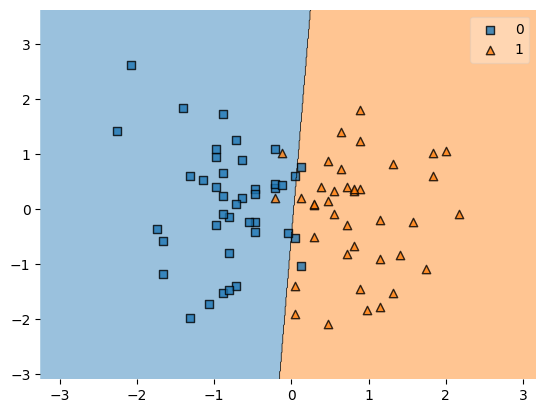

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=clf)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf, open('model.pkl', 'wb'))